# Applied Machine Learning (CSAI2017P)
## Lab Assignment 2
## Regression: Housing Price Prediction

**Name:** Abhishek Bhatt

**SAP ID:** 590028847

**Batch:** 05

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

for m in (np, pd, sklearn):
    print(f"{m.__name__:12s} {m.__version__}")

numpy        2.4.1
pandas       3.0.0
sklearn      1.8.0


In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

## A1. Simple Linear Regression

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [6]:
X_single = X[['MedInc']]

X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
    X_single,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [7]:
model = LinearRegression()

model.fit(X_train_single, y_train_single)
y_pred = model.predict(X_test_single)
r2 = r2_score(y_test_single, y_pred)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("Test R²:", r2)

Slope: 0.4203217769894005
Intercept: 0.4432063522765708
Test R²: 0.4466846804895943


### Observation (A1)

- The model uses only **Median Income (MedInc)** to predict house prices.
- The positive slope indicates that house prices generally increase as median income increases.
- The model achieved an R² score of approximately **0.45**, showing that income alone explains a moderate portion of the variation in house prices.

## A2. Multiple Linear Regression

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [10]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.5351261336554507
RMSE: 0.7273129773603114
R²  : 0.5943232652466204


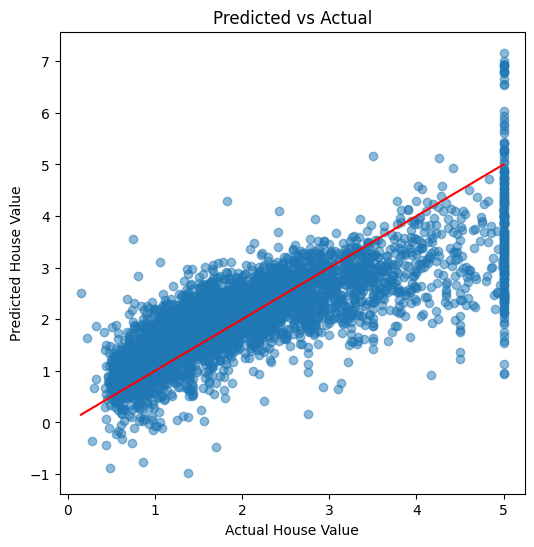

In [11]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Predicted vs Actual")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

### Observation (A2)

- The multiple linear regression model uses all eight features to predict house prices.
- The predicted values generally follow the actual values, but some points are scattered away from the ideal line.
- This indicates that the model captures the overall trend but still makes larger errors for some districts.

## A3. Metric Choice

In [12]:
mse = mean_squared_error(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 0.5351261336554507
MSE : 0.5289841670367208
RMSE: 0.7273129773603114


### Observation (A3)

- MAE and RMSE are measured in the same units as the target, while MSE is in squared units.
- MSE is the hardest metric to explain to a non-technical client because its values are squared.
- If very expensive districts are more important, RMSE is preferred because it penalizes larger prediction errors more heavily.

## B1. Polynomial Features and Over-fitting

In [13]:
from sklearn.preprocessing import PolynomialFeatures

In [14]:
results = []

best_model = None
best_rmse = float("inf")
best_prediction = None

for degree in [1, 2, 3]:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree)),
        ("linear", LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results.append([degree, train_rmse, test_rmse])

    if test_rmse < best_rmse:
        best_rmse = test_rmse
        best_model = model
        best_prediction = test_pred

results_df = pd.DataFrame(
    results,
    columns=["Degree", "Train RMSE", "Test RMSE"]
)

results_df

,Degree,Train RMSE,Test RMSE
0,1,0.723492,0.727313
1,2,0.647843,1.662482
2,3,0.587964,596.159435


### Observation (B1)

- As the polynomial degree increases, the model becomes more flexible.
- Degree 2 and degree 3 reduce the RMSE compared to degree 1, which means they capture more complex relationships.
- Over-fitting is not very strong if the test RMSE also decreases along with train RMSE.
- However, if the gap between train RMSE and test RMSE becomes larger at degree 3, it shows that over-fitting may be starting.

## C1. Where the Model Fails

In [15]:
errors = np.abs(y_test - best_prediction)

In [16]:
result = X_test.copy()

result["Actual"] = y_test.values
result["Predicted"] = best_prediction
result["Absolute Error"] = errors

In [17]:
top20 = result.sort_values(
    by="Absolute Error",
    ascending=False
).head(20)

top20

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Actual,Predicted,Absolute Error
12138,2.6250,16.0,4.000000,0.500000,39.0,2.785714,33.87,-117.22,5.00001,0.934598,4.065412
4861,0.4999,29.0,2.373272,1.055300,2690.0,12.396313,34.02,-118.28,5.00001,0.955760,4.044250
10574,1.9659,6.0,4.795455,1.159091,125.0,2.840909,33.72,-117.70,5.00001,1.139277,3.860733
16642,0.7025,19.0,2.425197,1.125984,1799.0,2.833071,35.30,-120.67,5.00001,1.537748,3.462262
6651,1.9923,41.0,3.279373,1.062663,855.0,2.232376,34.15,-118.14,5.00001,1.575507,3.424503
4630,2.3674,20.0,2.740554,1.047859,2919.0,2.450882,34.07,-118.31,5.00001,1.678140,3.321870
4623,0.8804,36.0,2.713235,1.080882,145.0,1.066176,34.06,-118.31,4.50000,1.236512,3.263488
13360,2.1250,6.0,5.904762,1.119048,119.0,2.833333,34.02,-117.64,4.16700,0.922637,3.244363
15615,1.8981,31.0,3.323064,1.091590,2305.0,1.919234,37.81,-122.41,5.00001,1.756510,3.243500
9168,1.9667,2.0,5.715976,1.597633,233.0,1.378698,34.42,-118.56,4.50000,1.356287,3.143713


### Observation (C1)

- The largest prediction errors are mainly found in districts with very high or very low house values.
- These districts may have characteristics that are not fully captured by the available features.
- Additional information such as neighborhood quality, crime rate, school ratings, or distance to important facilities could improve the model's predictions.